In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [2]:
!pip install seaborn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, root_mean_squared_error,
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

In [6]:
sns.set(style="whitegrid")
%matplotlib inline
RANDOM_STATE = 45

In [8]:
df = pd.read_csv('dirty_cafe_sales_processed.csv')
print("Размер:", df.shape)
df.head()

Размер: (10000, 15)


,Transaction ID,Quantity,Price Per Unit,Total Spent,Transaction Date,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Takeaway
0,TXN_1961373,0.25,0.25,0.125000,2023-09-08,True,False,False,False,False,False,False,True,False,True
1,TXN_4977031,0.75,0.50,0.458333,2023-05-16,False,False,False,False,False,False,False,False,False,False
2,TXN_4271903,0.75,0.00,0.291667,2023-07-19,False,True,False,False,False,False,False,True,False,False
3,TXN_7034554,0.25,1.00,0.375000,2023-04-27,False,False,False,True,False,False,False,False,True,True
4,TXN_3160411,0.25,0.25,0.125000,2023-06-11,True,False,False,False,False,False,False,False,True,False


In [9]:
print("Все колонки:")
print(df.columns.tolist())
print("\nТипы:")
print(df.dtypes.value_counts())
print("\nПропуски:", df.isna().sum().sum())

Все колонки:
['Transaction ID', 'Quantity', 'Price Per Unit', 'Total Spent', 'Transaction Date', 'Item_Coffee', 'Item_Cookie', 'Item_Juice', 'Item_Salad', 'Item_Sandwich', 'Item_Smoothie', 'Item_Tea', 'Payment Method_Credit Card', 'Payment Method_Digital Wallet', 'Location_Takeaway']

Типы:
bool       10
float64     3
str         2
Name: count, dtype: int64

Пропуски: 0


In [10]:
df_model = df.drop(columns=['Transaction ID']).copy()
print("Размер:", df_model.shape)
print("Колонки:", df_model.columns.tolist())

Размер: (10000, 14)
Колонки: ['Quantity', 'Price Per Unit', 'Total Spent', 'Transaction Date', 'Item_Coffee', 'Item_Cookie', 'Item_Juice', 'Item_Salad', 'Item_Sandwich', 'Item_Smoothie', 'Item_Tea', 'Payment Method_Credit Card', 'Payment Method_Digital Wallet', 'Location_Takeaway']


In [11]:
TARGET_REG = 'Total Spent'

X_reg = df_model.drop(columns=[TARGET_REG, 'Transaction Date'])
y_reg = df_model[TARGET_REG]

print("X:", X_reg.shape, "| y:", y_reg.shape)
print("Признаки:", X_reg.columns.tolist())

X: (10000, 12) | y: (10000,)
Признаки: ['Quantity', 'Price Per Unit', 'Item_Coffee', 'Item_Cookie', 'Item_Juice', 'Item_Salad', 'Item_Sandwich', 'Item_Smoothie', 'Item_Tea', 'Payment Method_Credit Card', 'Payment Method_Digital Wallet', 'Location_Takeaway']


In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_reg, y_reg, test_size=0.4, random_state=RANDOM_STATE
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (6000, 12)
Val:   (2000, 12)
Test:  (2000, 12)


In [13]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

rmse_lin = root_mean_squared_error(y_test, y_pred_lin)
mae_lin  = mean_absolute_error(y_test, y_pred_lin)

print(f"Linear — RMSE: {rmse_lin:.4f}, MAE: {mae_lin:.4f}")

Linear — RMSE: 0.0987, MAE: 0.0681


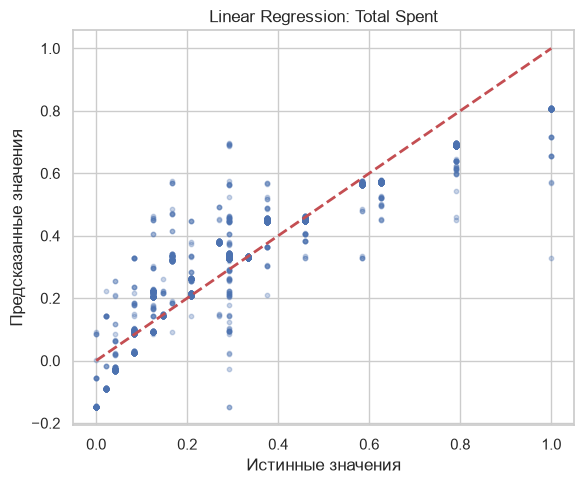

In [14]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_lin, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Linear Regression: Total Spent')
plt.tight_layout()
plt.show()

In [15]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)

rmse_poly = root_mean_squared_error(y_test, y_pred_poly)
mae_poly  = mean_absolute_error(y_test, y_pred_poly)

print(f"Poly(2) — RMSE: {rmse_poly:.4f}, MAE: {mae_poly:.4f}")

Poly(2) — RMSE: 0.0652, MAE: 0.0276


In [16]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

ridge = Ridge(alpha=1.0).fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

lasso = Lasso(alpha=0.01).fit(X_train_sc, y_train)
y_pred_lasso = lasso.predict(X_test_sc)

print(f"Ridge — RMSE: {root_mean_squared_error(y_test, y_pred_ridge):.4f}")
print(f"Lasso — RMSE: {root_mean_squared_error(y_test, y_pred_lasso):.4f}")

Ridge — RMSE: 0.0987
Lasso — RMSE: 0.1027


In [17]:
results = pd.DataFrame({
    'Model': ['Linear', 'Poly(2)', 'Ridge', 'Lasso'],
    'RMSE': [
        root_mean_squared_error(y_test, y_pred_lin),
        root_mean_squared_error(y_test, y_pred_poly),
        root_mean_squared_error(y_test, y_pred_ridge),
        root_mean_squared_error(y_test, y_pred_lasso),
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lin),
        mean_absolute_error(y_test, y_pred_poly),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
    ]
}).sort_values('RMSE').reset_index(drop=True)

results

,Model,RMSE,MAE
0,Poly(2),0.065245,0.027642
1,Linear,0.098688,0.068127
2,Ridge,0.098688,0.068133
3,Lasso,0.102681,0.072577


In [18]:
item_cols = [c for c in df_model.columns if c.startswith('Item_')]
print("One-Hot колонки товаров:", item_cols)

df_model['Item_Label'] = df_model[item_cols].idxmax(axis=1).str.replace('Item_', '')

print("\nРаспределение классов:")
print(df_model['Item_Label'].value_counts())

One-Hot колонки товаров: ['Item_Coffee', 'Item_Cookie', 'Item_Juice', 'Item_Salad', 'Item_Sandwich', 'Item_Smoothie', 'Item_Tea']

Распределение классов:
Item_Label
Coffee      2304
Juice       2140
Salad       1148
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64


In [19]:
TARGET_CLF = 'Item_Label'

X_clf = df_model.drop(columns=[TARGET_CLF, 'Transaction Date', 'Total Spent'] + item_cols)
y_clf = df_model[TARGET_CLF]

print("X:", X_clf.shape)
print("Признаки:", X_clf.columns.tolist())
print("Классы:", sorted(y_clf.unique()))

X: (10000, 5)
Признаки: ['Quantity', 'Price Per Unit', 'Payment Method_Credit Card', 'Payment Method_Digital Wallet', 'Location_Takeaway']
Классы: ['Coffee', 'Cookie', 'Juice', 'Salad', 'Sandwich', 'Smoothie', 'Tea']


In [20]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_clf
)

scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

print(f"Train: {X_train_c.shape}, Test: {X_test_c.shape}")

Train: (8000, 5), Test: (2000, 5)


In [21]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_c_sc, y_train_c)
y_pred_c = logreg.predict(X_test_c_sc)

print(f"Accuracy:  {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_c, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test_c, y_pred_c, average='weighted', zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test_c, y_pred_c, average='weighted', zero_division=0):.4f}")

Accuracy:  0.6785
Precision: 0.7114
Recall:    0.6785
F1:        0.6765


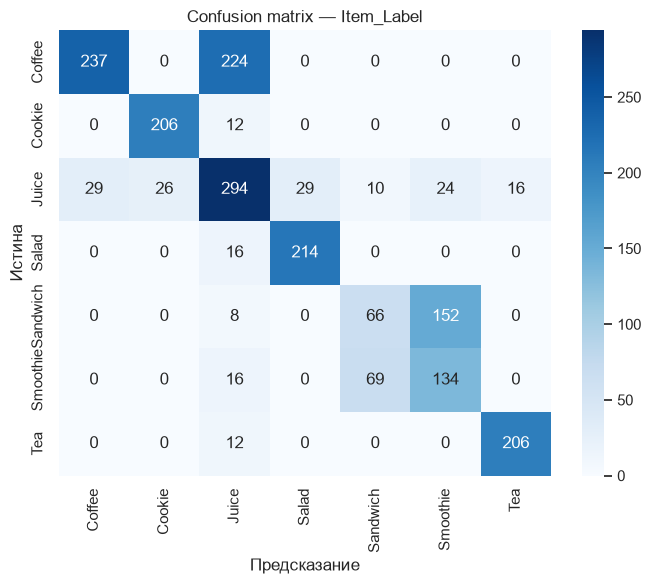

In [22]:
cm = confusion_matrix(y_test_c, y_pred_c, labels=logreg.classes_)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=logreg.classes_,
            yticklabels=logreg.classes_)
plt.title('Confusion matrix — Item_Label')
plt.ylabel('Истина')
plt.xlabel('Предсказание')
plt.tight_layout()
plt.show()

In [23]:
print(classification_report(y_test_c, y_pred_c, zero_division=0))

              precision    recall  f1-score   support

      Coffee       0.89      0.51      0.65       461
      Cookie       0.89      0.94      0.92       218
       Juice       0.51      0.69      0.58       428
       Salad       0.88      0.93      0.90       230
    Sandwich       0.46      0.29      0.36       226
    Smoothie       0.43      0.61      0.51       219
         Tea       0.93      0.94      0.94       218

    accuracy                           0.68      2000
   macro avg       0.71      0.70      0.69      2000
weighted avg       0.71      0.68      0.68      2000



In [24]:
logreg_bal = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
)
logreg_bal.fit(X_train_c_sc, y_train_c)
y_pred_bal = logreg_bal.predict(X_test_c_sc)

print(f"Accuracy:  {accuracy_score(y_test_c, y_pred_bal):.4f}")
print(f"F1 (weighted): {f1_score(y_test_c, y_pred_bal, average='weighted', zero_division=0):.4f}")
print(f"F1 (macro):    {f1_score(y_test_c, y_pred_bal, average='macro', zero_division=0):.4f}")

Accuracy:  0.6190
F1 (weighted): 0.5941
F1 (macro):    0.6260


In [25]:
comparison = pd.DataFrame({
    'Model': ['LogReg', 'LogReg (balanced)'],
    'Accuracy': [
        accuracy_score(y_test_c, y_pred_c),
        accuracy_score(y_test_c, y_pred_bal),
    ],
    'F1 (weighted)': [
        f1_score(y_test_c, y_pred_c, average='weighted', zero_division=0),
        f1_score(y_test_c, y_pred_bal, average='weighted', zero_division=0),
    ],
    'F1 (macro)': [
        f1_score(y_test_c, y_pred_c, average='macro', zero_division=0),
        f1_score(y_test_c, y_pred_bal, average='macro', zero_division=0),
    ],
})

comparison

,Model,Accuracy,F1 (weighted),F1 (macro)
0,LogReg,0.6785,0.676469,0.693338
1,LogReg (balanced),0.6190,0.594056,0.625989


In [29]:
results.to_csv('regression_results.csv', index=False)

with open('classification_report.txt', 'w', encoding='utf-8') as f:
    f.write("Регрессия: Total Spent\n")
    f.write(results.to_string(index=False))
    f.write("\n\nКлассификация: Item_Label\n")
    f.write(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}\n")
    f.write(f"F1 (weighted): {f1_score(y_test_c, y_pred_c, average='weighted', zero_division=0):.4f}\n\n")
    f.write(classification_report(y_test_c, y_pred_c, zero_division=0))

print("  - regression_results.csv")
print("  - classification_report.txt")

  - regression_results.csv
  - classification_report.txt
